In [21]:
import sys
sys.path.append("../src")
# from linear_foraging import foraging_playground_linear
import numpy as np
# from foraging_utils import optimal_linear, chance_linear, register_custom_env
import matplotlib.pyplot as plt
import gymnasium as gym
import pickle
from matplotlib.ticker import MultipleLocator
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
import torch.nn as nn
import torch
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards
from treeple.ensemble import ObliqueRandomForestRegressor
import xgboost as xgb

In [22]:
base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 5000000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)

In [23]:
def get_candidates(state, t):
    if state == 0:
        return [1, 0]
    elif state == 6:
        return [5, 6]
    else:
        # default 3-way split for illustration
        return [state-1, state, state+1]

def enumerate_paths(x0, t_inital = 0, t_prime=20):
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates(curr, t):
                new_paths.append(path + [nxt])
        paths = new_paths
    
    # Convert to DataFrame: each row is one path, columns t=0..T
    cols = [f"t={t_inital+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df


1280000
(1280000, 57) (1280000,)
[0.68004723 0.72882362 0.22338313] [0.11169095 0.36441119 0.72882362]
1280000 train done
0.9032269644182199


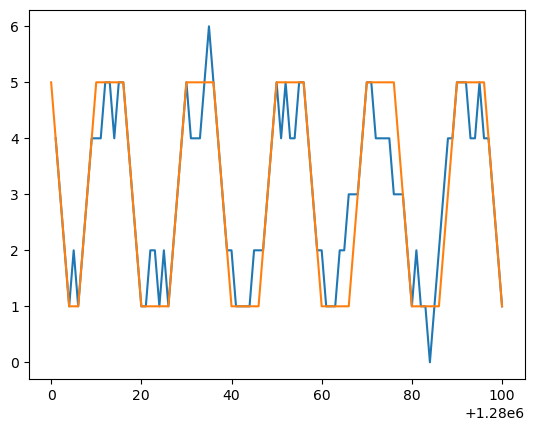

In [ ]:
DELTA_t = 20
t_prime = 6
Ts = [1000,5000,10000,20000,40000,80000,160000,320000,640000]
Ts = [1280000]
# Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
gamma = 0.5
FUTURE_STATE = []
for T in Ts:
    # n_seq = int(T/(DELTA_t+1))
    np.random.seed(1998)
    n_seq = T
    print(n_seq)
    state_raw = np.random.choice([int(i) for i in range(7)],size = n_seq)
    time_raw = np.random.choice([int(i) for i in range(T-DELTA_t)],size = n_seq)
    opt_paths, opt_times, opt_irewards, opt_prewards = [], [], [], []
    STATES = []
    for i in range(len(time_raw)):
        path, rewards = path_opt(state_raw[i], time_raw[i], DELTA_t)
        # print(state_raw[i],path)
        times = [time_raw[i]+delta_t for delta_t in np.arange(1,DELTA_t+2)] # raw time begin from 1
        opt_paths.append(path)
        opt_irewards.append(rewards)
        opt_times.append(times)
        opt_prewards.append(preward_opt(rewards[1:],gamma = gamma))
        state_posencode_oh = position_encoder(np.array(path), type="onehot")
        time_emb = time_embedding_np(np.array(times)).reshape(DELTA_t+1,-1)
        # print(time_emb.shape,state_posencode_oh.shape)
        state_pe = np.hstack([state_posencode_oh,time_emb])
        STATES.append(state_pe[0,:])
    STATES_arr = np.vstack(STATES)
    REWARDS_arr = np.hstack(np.array(opt_prewards).reshape(-1,1))
    print(STATES_arr.shape,REWARDS_arr.shape)
    print(REWARDS_arr[:3],REWARDS_arr[-3:])
    X_train = STATES_arr
    Y_train = REWARDS_arr
    # rf = RandomForestRegressor(n_estimators=1000, random_state=515)
    ## Using XGB regressor with delta = 1 is converging faster -- 150
    rf = xgb.XGBRegressor(
        objective="reg:squarederror",
        tree_method="exact",     # or "exact" (slower, RAM heavy)
        n_jobs = -1,
        learning_rate=0.05, max_depth=10,
        subsample=1, colsample_bytree=0.8,
        n_estimators=5000, eval_metric="rmse"
    )
    rf.fit(X_train, Y_train)
    print(T,'train done')

    
    current_state = np.random.choice([int(i) for i in range(7)],size = 1)
    future_states = [current_state.item()]
    # print(current_state)
    irewards_test = []
    for delta_t in range(100):
        df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
        n_paths = df_all_paths.shape[0]
        prewards_pred = np.zeros((n_paths,  t_prime+1))
        for i in range(t_prime+1):
            cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
            curr_time = T+1+delta_t+i
            time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
            features = np.hstack([cand_pe,time_emb])
            prewards_pred[:,i] = rf.predict(features)
        idx_sorted = np.lexsort([prewards_pred[:, j] for j in [1,-1]])
        best_idx = idx_sorted[-1]
        best_path = df_all_paths.iloc[best_idx,:]
        next_state = np.array(best_path)[1]
        future_states.append(next_state.item())
        irewards_test.append(reward_simulate(next_state,T+delta_t+1,rewards_in_period))
        current_state = next_state
    # print(T,future_states,len(future_states))
    FUTURE_STATE.append(future_states)

    irewards = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
    preward = compute_normalized_future_rewards(irewards,100,gamma)
    path, ireward_opt = path_opt(future_states[0], T, 100)
    preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,gamma)
    pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
    print(pregret)
    plt.plot(np.arange(T+1,T+101),future_states[1:])
    plt.plot(np.arange(T,T+101),path)
    plt.show()

FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
np.savez(
    f"../results/PVFM/RF_optimal_oh_w_time1000_640000_lookahead{t_prime}_reps{0}.npz",
    future_states =FUTURE_STATE_arr
    )



# PVFM - Onehot - RF

In [24]:
t_prime = 6
Ts = [1000,5000,10000,20000,40000,80000]
# Ts = [1280000]
# Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
gamma = 0.5
for rep in np.arange(8,10):
    FUTURE_STATE = []
    actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                    session_duration = 500000,
                                                    tdim=50, 
                                                    n_sessions=1,seed  = 515+rep)
    state_posencode_oh = position_encoder(states[:,0], type="onehot")
    new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])
    for T in Ts:
        print('training timestamps', T)
        prewards = make_weighted_target(irewards, gamma ,T = T)
        X_train = new_state_oh[:T,:]
        Y_train = prewards[:T]
        rf= RandomForestRegressor(n_estimators=1000, random_state=1998+515+rep)
        rf.fit(X_train, Y_train)
        print(T,'train done')
        current_state = np.random.choice([int(i) for i in range(7)],size = 1)
        future_states = [current_state.item()]
        # print(current_state)
        irewards_test = []
        for delta_t in range(100):
            df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
            n_paths = df_all_paths.shape[0]
            prewards_pred = np.zeros((n_paths,  t_prime+1))
            for i in range(t_prime+1):
                cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                curr_time = T+1+delta_t+i
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                prewards_pred[:,i] = rf.predict(features)
            # idx_sorted = np.lexsort([prewards_pred[:, j] for j in [1,-1]])
            idx_sorted = np.lexsort([prewards_pred[:, j] for j in [1]])
            best_idx = idx_sorted[-1]
            best_path = df_all_paths.iloc[best_idx,:]
            next_state = np.array(best_path)[1]
            future_states.append(next_state.item())
            irewards_test.append(reward_simulate(next_state,T+delta_t+1,rewards_in_period))
            current_state = next_state
        # print(T,future_states,len(future_states))
        FUTURE_STATE.append(future_states)

        irewards_future = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
        preward = compute_normalized_future_rewards(irewards_future,100,gamma)
        path, ireward_opt = path_opt(future_states[0], T, 100)
        preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,gamma)
        pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
        print(pregret)
        # plt.plot(np.arange(T+1,T+101),future_states[1:])
        # plt.plot(np.arange(T,T+101),path)
        # plt.show()

    FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
    np.savez(
        f"../results/PVFM/RF_oh_w_time1000_80000_wo_lookahead{t_prime}_reps{rep}.npz",
        future_states =FUTURE_STATE_arr
        )



training timestamps 1000
1000 train done
1.9793619167929193
training timestamps 5000
5000 train done
1.8457258934010035
training timestamps 10000
10000 train done
2.000100824459517
training timestamps 20000
20000 train done
1.8457116709516714
training timestamps 40000
40000 train done
1.6902301436014968
training timestamps 80000
80000 train done
1.2546180404630507
training timestamps 1000
1000 train done
2.3720876276825975
training timestamps 5000
5000 train done
1.954582505097526
training timestamps 10000
10000 train done
2.070300656952691
training timestamps 20000
20000 train done
2.1136919002054624
training timestamps 40000
40000 train done
1.7031685197184065
training timestamps 80000
80000 train done
1.3568396759471721


# PVFM - Onehot - XGB

In [ ]:
t_prime = 6
Ts = [1000,5000,10000,20000,40000,80000,160000,320000]
# Ts = [1280000]
# Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
gamma = 0.5
FUTURE_STATE = []
actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                session_duration = 500000,
                                                tdim=50, 
                                                n_sessions=1,seed  = 8515)
state_posencode_oh = position_encoder(states[:,0], type="onehot")
new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])
for T in Ts:
    print('training timestamps', T)
    prewards = make_weighted_target(irewards, gamma ,T = T)
    X_train = new_state_oh[:T,:]
    Y_train = prewards[:T]
    # rf= RandomForestRegressor(n_estimators=1000, random_state=515)
    rf = xgb.XGBRegressor(
            objective="reg:squarederror",
            tree_method="exact",     # or "exact" (slower, RAM heavy)
            n_jobs = -1,
            learning_rate=0.05, max_depth=10,
            subsample=1, colsample_bytree=0.8,
            n_estimators=2000, eval_metric="rmse"
        )
    rf.fit(X_train, Y_train)
    print(T,'train done')
    current_state = np.random.choice([int(i) for i in range(7)],size = 1)
    future_states = [current_state.item()]
    # print(current_state)
    irewards_test = []
    for delta_t in range(100):
        df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
        n_paths = df_all_paths.shape[0]
        prewards_pred = np.zeros((n_paths,  t_prime+1))
        for i in range(t_prime+1):
            cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
            curr_time = T+1+delta_t+i
            time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
            features = np.hstack([cand_pe,time_emb])
            prewards_pred[:,i] = rf.predict(features)
        idx_sorted = np.lexsort([prewards_pred[:, j] for j in [1,-1]])
        best_idx = idx_sorted[-1]
        best_path = df_all_paths.iloc[best_idx,:]
        next_state = np.array(best_path)[1]
        future_states.append(next_state.item())
        irewards_test.append(reward_simulate(next_state,T+delta_t+1,rewards_in_period))
        current_state = next_state
    # print(T,future_states,len(future_states))
    FUTURE_STATE.append(future_states)

    irewards_future = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
    preward = compute_normalized_future_rewards(irewards_future,100,gamma)
    path, ireward_opt = path_opt(future_states[0], T, 100)
    preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,gamma)
    pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
    print(pregret)
    plt.plot(np.arange(T+1,T+101),future_states[1:])
    plt.plot(np.arange(T,T+101),path)
    plt.show()

FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
np.savez(
    f"../results/PVFM/GBT_oh_w_time1000_320000_lookahead{t_prime}_reps{0}.npz",
    future_states =FUTURE_STATE_arr
    )

